# Kalman Filters for Financial Feature Extraction

**Docker image**: `ml4t`

This notebook demonstrates the Kalman filter as a production feature
extractor: level estimation, trend detection, innovation (surprise)
signals, and dynamic hedge ratio estimation.

**Learning Objectives**:
- Implement the local linear trend Kalman filter from scratch
- Extract four production features: level, slope, innovation, uncertainty
- Estimate time-varying hedge ratios for pairs trading
- Compare Kalman features with EMA and rolling OLS baselines
- Understand MLE-based noise covariance estimation

**Book Reference**: Chapter 9, Section 9.2 (Signal Transforms: State, Frequency, Scale, and Path Features)

**Prerequisites**: Basic linear algebra (matrix multiplication, inversion).

In [1]:
"""Kalman Filters — state-space feature extraction for trading systems."""

import warnings
from typing import Any

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from scipy.optimize import minimize
from scipy.stats import linregress

from data import load_etfs

In [2]:
# Production defaults — Papermill injects overrides for CI
START_DATE = "2018-01-01"
END_DATE = "2023-12-31"

## Load Data

In [3]:
etfs = load_etfs()

spy = etfs.filter(pl.col("symbol") == "SPY").sort("timestamp")
spy_filtered = spy.filter(
    (pl.col("timestamp") >= pl.lit(START_DATE).str.to_date())
    & (pl.col("timestamp") <= pl.lit(END_DATE).str.to_date())
)

prices = spy_filtered["close"].to_numpy()
timestamps = spy_filtered["timestamp"].to_list()

print(f"SPY: {len(prices):,} observations ({timestamps[0]} to {timestamps[-1]})")

SPY: 1,509 observations (2018-01-02 to 2023-12-29)


## Local Linear Trend Model

The state-space formulation:

**State**: $\mathbf{x}_t = [\text{level}_t, \text{slope}_t]^\top$

**Transition**: $\mathbf{x}_t = \mathbf{F} \mathbf{x}_{t-1} + \mathbf{w}_t$
where $\mathbf{F} = \begin{bmatrix} 1 & 1 \\ 0 & 1 \end{bmatrix}$

**Observation**: $y_t = \mathbf{H} \mathbf{x}_t + v_t$
where $\mathbf{H} = [1, 0]$

The **predict-update** cycle:
1. **Predict**: project state and covariance forward
2. **Innovation**: compute prediction error $y_t - \hat{y}_t$
3. **Update**: adjust state using Kalman gain $\mathbf{K}$

In [4]:
def kalman_local_linear(
    prices: np.ndarray,
    observation_noise: float = 1.0,
    level_noise: float = 0.01,
    slope_noise: float = 0.001,
) -> dict[str, Any]:
    """Local linear trend Kalman filter with full feature outputs.

    State: [level, slope]
    Observation: price = level + noise

    Returns dict with level, slope, innovation, uncertainty, log_likelihood.
    """
    n = len(prices)

    # State transition: level_t = level_{t-1} + slope_{t-1}, slope_t = slope_{t-1}
    F = np.array([[1.0, 1.0], [0.0, 1.0]])
    H = np.array([[1.0, 0.0]])

    Q = np.array([[level_noise, 0.0], [0.0, slope_noise]])
    R = np.array([[observation_noise]])

    # Initialize
    x = np.array([prices[0], 0.0])
    P = np.eye(2) * 10.0

    levels = np.zeros(n)
    slopes = np.zeros(n)
    innovations = np.zeros(n)
    uncertainties = np.zeros(n)
    log_likelihood = 0.0

    for t in range(n):
        # Predict
        x_pred = F @ x
        P_pred = F @ P @ F.T + Q

        # Innovation
        y = prices[t] - H @ x_pred
        S = H @ P_pred @ H.T + R

        # Log-likelihood contribution
        log_likelihood += -0.5 * (np.log(2 * np.pi * S[0, 0]) + y[0] ** 2 / S[0, 0])

        # Kalman gain
        K = P_pred @ H.T @ np.linalg.inv(S)

        # Update
        x = x_pred + K @ y
        P = (np.eye(2) - K @ H) @ P_pred

        levels[t] = x[0]
        slopes[t] = x[1]
        innovations[t] = y[0]
        uncertainties[t] = P[0, 0]

    return {
        "level": levels,
        "slope": slopes,
        "innovation": innovations,
        "uncertainty": uncertainties,
        "log_likelihood": log_likelihood,
    }


kf = kalman_local_linear(prices, observation_noise=1.0, level_noise=0.01, slope_noise=0.001)
print(f"Log-likelihood: {kf['log_likelihood']:.2f}")

Log-likelihood: -21854.96


### Visualize Kalman Features

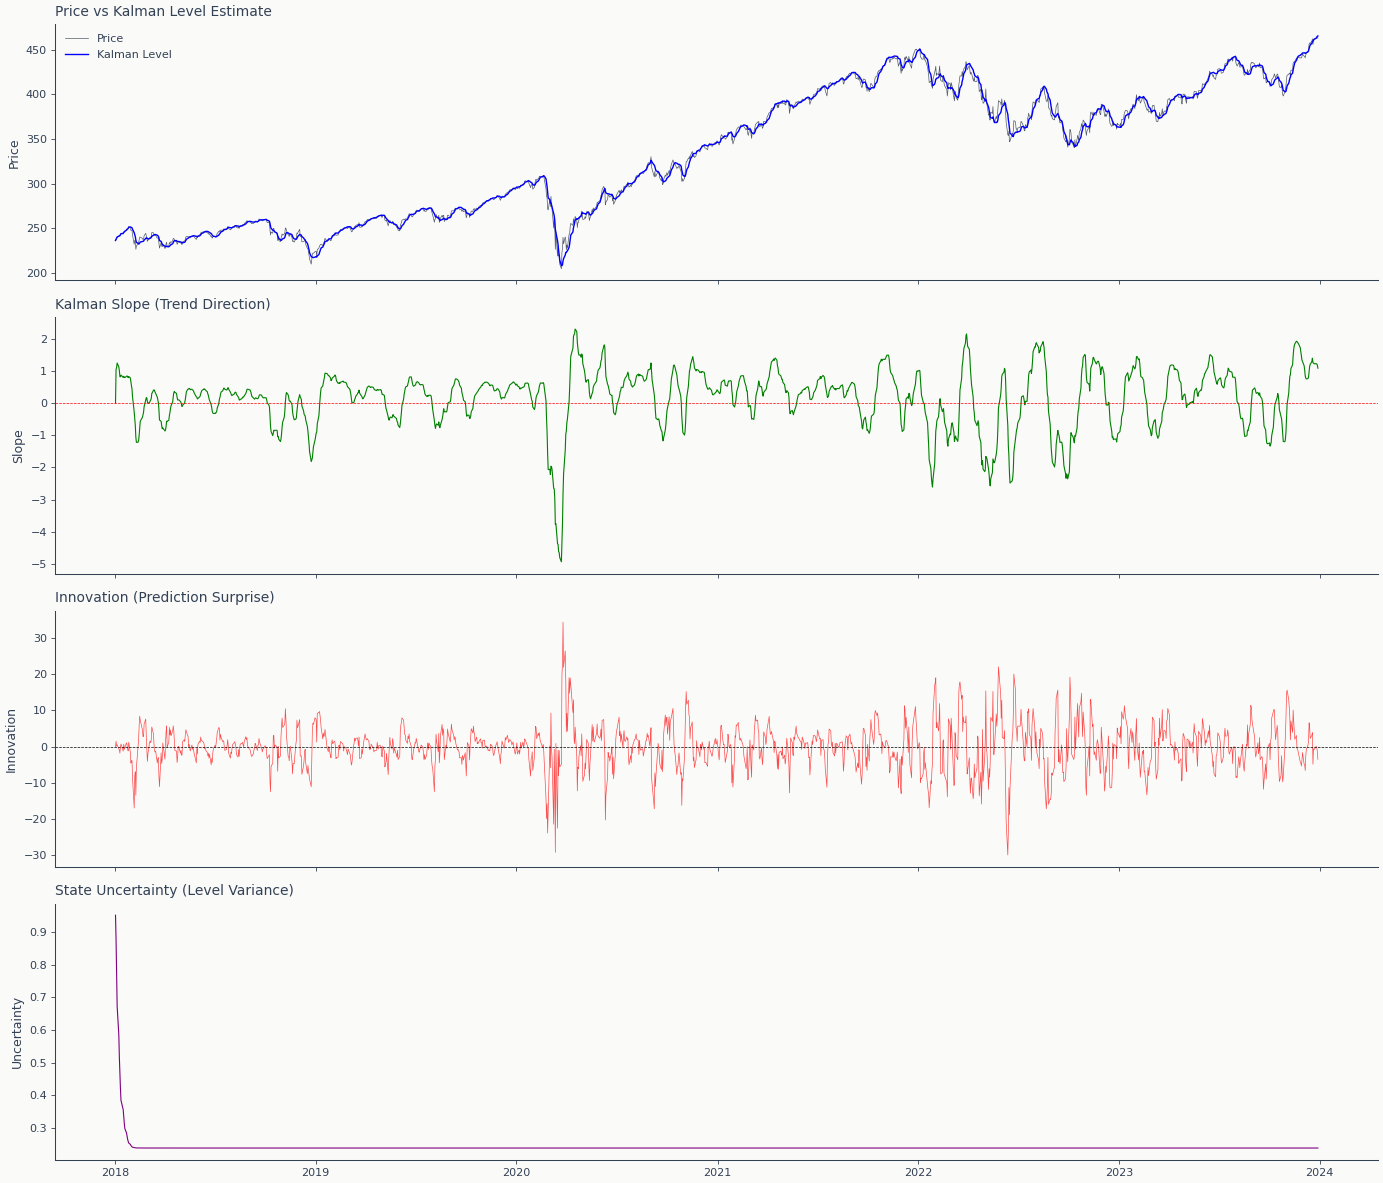

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

ax = axes[0]
ax.plot(timestamps, prices, linewidth=0.5, alpha=0.7, label="Price")
ax.plot(timestamps, kf["level"], linewidth=1, label="Kalman Level", color="blue")
ax.set_title("Price vs Kalman Level Estimate")
ax.set_ylabel("Price")
ax.legend()

ax = axes[1]
ax.plot(timestamps, kf["slope"], linewidth=0.8, color="green")
ax.axhline(0, color="red", linestyle="--", linewidth=0.5)
ax.set_title("Kalman Slope (Trend Direction)")
ax.set_ylabel("Slope")

ax = axes[2]
ax.plot(timestamps, kf["innovation"], linewidth=0.5, alpha=0.7, color="red")
ax.axhline(0, color="black", linestyle="--", linewidth=0.5)
ax.set_title("Innovation (Prediction Surprise)")
ax.set_ylabel("Innovation")

ax = axes[3]
ax.plot(timestamps, kf["uncertainty"], linewidth=0.8, color="purple")
ax.set_title("State Uncertainty (Level Variance)")
ax.set_ylabel("Uncertainty")

plt.tight_layout()
plt.show()

### MLE Noise Covariance Estimation

The noise parameters $(R, Q)$ control the filter's responsiveness.
Instead of guessing, optimize them via maximum likelihood.

In [6]:
def neg_log_likelihood(params: np.ndarray, prices: np.ndarray) -> float:
    """Negative log-likelihood for Kalman filter parameter optimization."""
    obs_noise = np.exp(params[0])  # Ensure positive
    level_noise = np.exp(params[1])
    slope_noise = np.exp(params[2])

    result = kalman_local_linear(prices, obs_noise, level_noise, slope_noise)
    return -result["log_likelihood"]


# Optimize
x0 = np.log([1.0, 0.01, 0.001])  # Initial log-params
opt = minimize(
    neg_log_likelihood, x0, args=(prices,), method="Nelder-Mead", options={"maxiter": 500}
)

opt_params = np.exp(opt.x)
print("=== MLE Noise Parameters ===")
print(f"Observation noise (R): {opt_params[0]:.4f}")
print(f"Level noise (Q_level): {opt_params[1]:.6f}")
print(f"Slope noise (Q_slope): {opt_params[2]:.6f}")
print(f"Optimized log-lik: {-opt.fun:.2f} (vs default: {kf['log_likelihood']:.2f})")

# Re-run with optimized parameters
kf_opt = kalman_local_linear(prices, *opt_params)

=== MLE Noise Parameters ===
Observation noise (R): 1.2124
Level noise (Q_level): 13.615959
Slope noise (Q_slope): 0.000000
Optimized log-lik: -4233.69 (vs default: -21854.96)


MLE finds that level noise ($Q_\text{level}$) dominates observation noise ($R$),
so the filter tracks prices closely rather than smoothing aggressively. The
unconstrained Nelder-Mead optimizer also drives slope noise ($Q_\text{slope}$)
to its numerical floor — a known degenerate corner: with no observation
carrying explicit slope information, the likelihood is flat as $Q_\text{slope}$
approaches zero. The walk-forward refit further down floors slope noise via
`L-BFGS-B` bounds to avoid this artifact in production use.

## Compare with EMA and Rolling OLS

Kalman filtering adapts its effective gain to the signal-to-noise ratio,
unlike fixed-window methods.

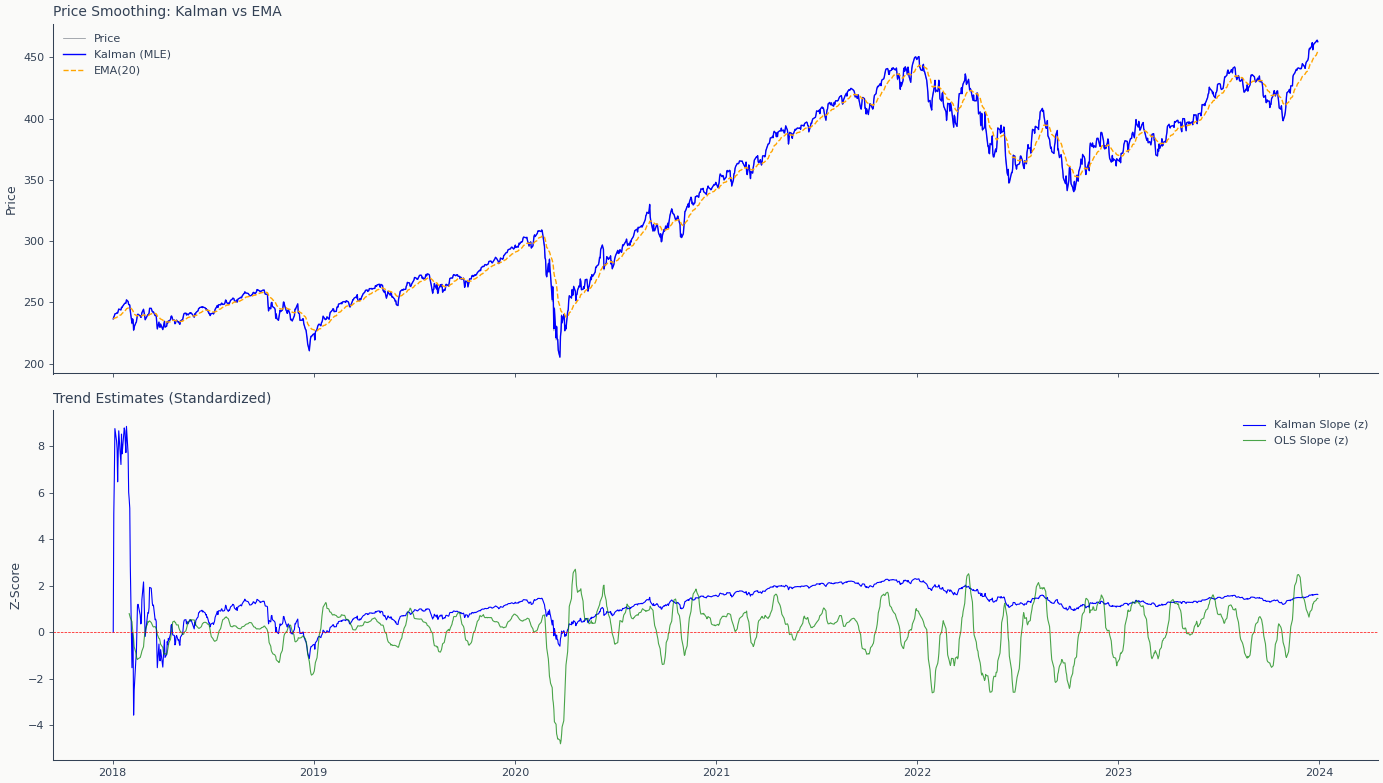

In [7]:
window = 20

# EMA
ema = np.zeros(len(prices))
alpha = 2 / (window + 1)
ema[0] = prices[0]
for t in range(1, len(prices)):
    ema[t] = alpha * prices[t] + (1 - alpha) * ema[t - 1]

# Rolling OLS slope
roll_slopes = np.full(len(prices), np.nan)
for t in range(window, len(prices)):
    x = np.arange(window)
    y = prices[t - window : t]
    slope, _, _, _, _ = linregress(x, y)
    roll_slopes[t] = slope

# Compare smoothing
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
ax.plot(timestamps, prices, linewidth=0.5, alpha=0.5, label="Price")
ax.plot(timestamps, kf_opt["level"], linewidth=1, label="Kalman (MLE)", color="blue")
ax.plot(timestamps, ema, linewidth=1, label="EMA(20)", linestyle="--", color="orange")
ax.set_title("Price Smoothing: Kalman vs EMA")
ax.set_ylabel("Price")
ax.legend()

# Compare slopes
kf_slope_z = kf_opt["slope"] / np.nanstd(kf_opt["slope"])
roll_slope_z = roll_slopes / np.nanstd(roll_slopes[~np.isnan(roll_slopes)])

ax = axes[1]
ax.plot(timestamps, kf_slope_z, linewidth=0.8, label="Kalman Slope (z)", color="blue")
ax.plot(timestamps, roll_slope_z, linewidth=0.8, label="OLS Slope (z)", color="green", alpha=0.7)
ax.axhline(0, color="red", linestyle="--", linewidth=0.5)
ax.set_title("Trend Estimates (Standardized)")
ax.set_ylabel("Z-Score")
ax.legend()

plt.tight_layout()
plt.show()

### Information Coefficient Comparison

Which trend estimate has better predictive value for future returns?

In [8]:
fwd_ret_5d = np.full(len(prices), np.nan)
fwd_ret_5d[:-5] = (prices[5:] - prices[:-5]) / prices[:-5]

features = {
    "kf_slope": kf_opt["slope"],
    "kf_innovation": kf_opt["innovation"],
    "roll_slope_20": roll_slopes,
}

print("=== IC: Correlation with 5-Day Forward Returns ===")
for name, feat in features.items():
    valid = ~np.isnan(feat) & ~np.isnan(fwd_ret_5d) & (np.arange(len(feat)) >= 20)
    if valid.sum() > 50:
        ic = np.corrcoef(feat[valid], fwd_ret_5d[valid])[0, 1]
        print(f"  {name:<20s}: IC = {ic:+.4f}")

=== IC: Correlation with 5-Day Forward Returns ===
  kf_slope            : IC = -0.1564
  kf_innovation       : IC = -0.0288
  roll_slope_20       : IC = -0.0170


All three features show negative IC, indicating that positive trend estimates
predict negative forward returns over the next 5 days — consistent with
short-term mean reversion in SPY. The Kalman slope's IC (-0.16) is roughly
5× the magnitude of the 20-day rolling OLS slope (-0.02), so the Kalman
trend produces a stronger contrarian signal at the 5-day horizon than the
fixed-window alternative. The innovation feature also carries a small
negative IC, which is what we expect from a surprise-style mean-reversion
input: a positive prediction error precedes negative subsequent returns.

## Dynamic Hedge Ratio Estimation

For pairs trading: estimate time-varying $\beta$ in $y_t = \alpha_t + \beta_t x_t + \varepsilon_t$
using a Kalman filter with random-walk state evolution.

In [9]:
def kalman_hedge_ratio(x: np.ndarray, y: np.ndarray, delta: float = 1e-3) -> dict:
    """Estimate time-varying hedge ratio using Kalman filter.

    Model: y_t = beta_t * x_t + alpha_t + noise
    State: [beta, alpha] follow a random walk.
    """
    n = len(x)
    F = np.eye(2)
    Q = delta / (1 - delta) * np.eye(2)
    R = 1.0

    state = np.array([0.0, 0.0])
    P = np.eye(2)

    betas = np.zeros(n)
    alphas = np.zeros(n)
    innovations = np.zeros(n)
    uncertainties = np.zeros(n)

    for t in range(n):
        H = np.array([[x[t], 1.0]])

        state_pred = F @ state
        P_pred = F @ P @ F.T + Q

        y_pred = H @ state_pred
        innovation = y[t] - y_pred[0]
        S = H @ P_pred @ H.T + R

        K = P_pred @ H.T / S
        state = state_pred + K.flatten() * innovation
        P = (np.eye(2) - K @ H) @ P_pred

        betas[t] = state[0]
        alphas[t] = state[1]
        innovations[t] = innovation
        uncertainties[t] = P[0, 0]

    return {
        "beta": betas,
        "alpha": alphas,
        "innovation": innovations,
        "uncertainty": uncertainties,
    }

### SPY vs QQQ Hedge Ratio

Apply the dynamic hedge ratio to the SPY-QQQ pair and compare with
a 60-day rolling OLS estimate.

In [10]:
qqq = etfs.filter(pl.col("symbol") == "QQQ").sort("timestamp")
spy_df = spy_filtered.select(["timestamp", "close"]).rename({"close": "spy"})
qqq_df = qqq.select(["timestamp", "close"]).rename({"close": "qqq"})
paired = spy_df.join(qqq_df, on="timestamp", how="inner")

spy_px = paired["spy"].to_numpy()
qqq_px = paired["qqq"].to_numpy()
pair_dates = paired["timestamp"].to_list()

hedge = kalman_hedge_ratio(qqq_px, spy_px, delta=1e-3)

# Rolling OLS for comparison
roll_beta = np.full(len(spy_px), np.nan)
for t in range(60, len(spy_px)):
    slope, _, _, _, _ = linregress(qqq_px[t - 60 : t], spy_px[t - 60 : t])
    roll_beta[t] = slope

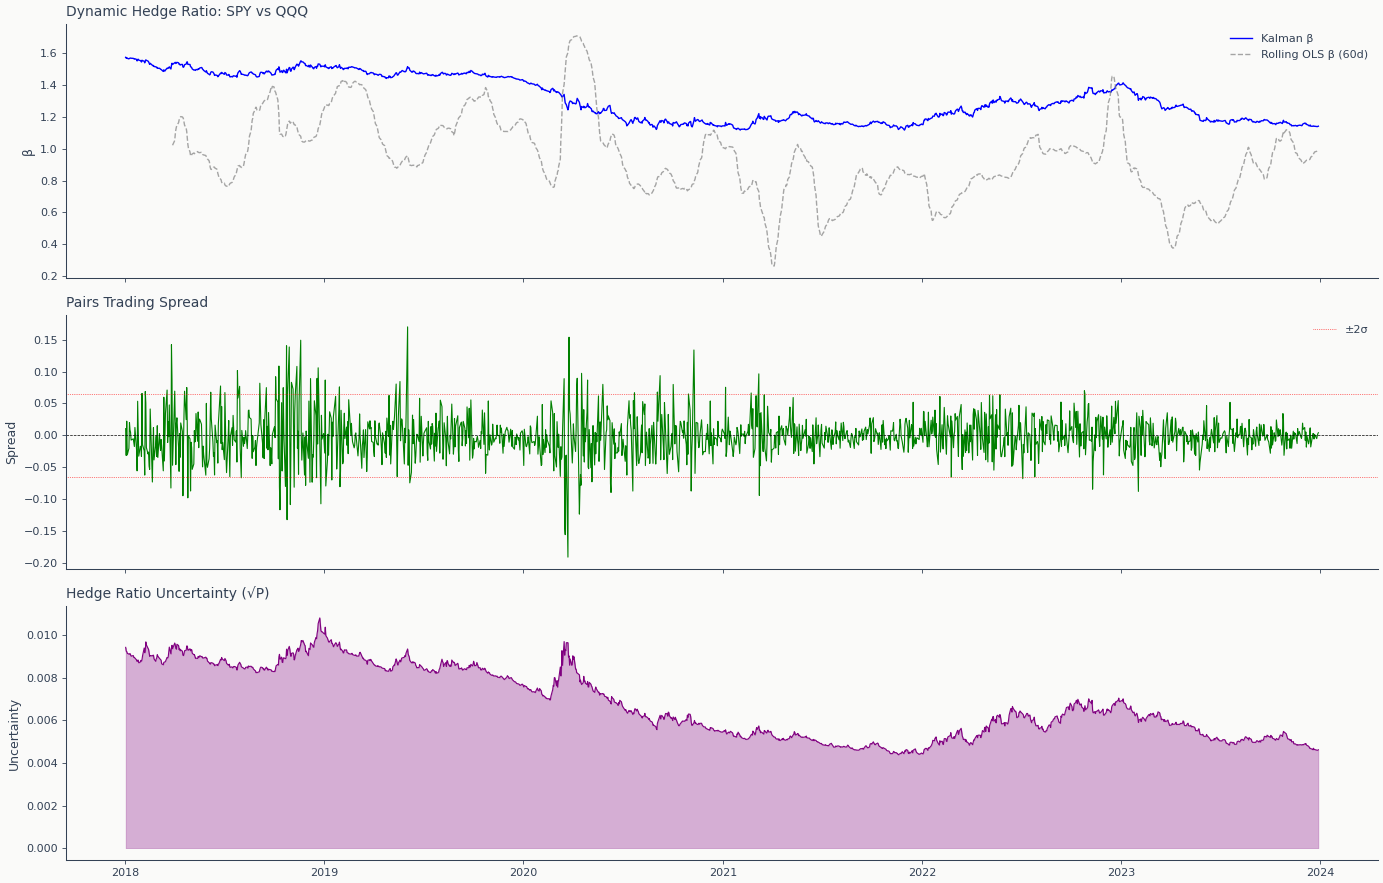

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

ax = axes[0]
ax.plot(pair_dates, hedge["beta"], linewidth=1, label="Kalman β", color="blue")
ax.plot(
    pair_dates,
    roll_beta,
    linewidth=1,
    label="Rolling OLS β (60d)",
    color="gray",
    linestyle="--",
    alpha=0.7,
)
ax.set_title("Dynamic Hedge Ratio: SPY vs QQQ")
ax.set_ylabel("β")
ax.legend()

ax = axes[1]
# Spread = SPY - β * QQQ - α
spread = spy_px - hedge["beta"] * qqq_px - hedge["alpha"]
ax.plot(pair_dates, spread, linewidth=0.8, color="green")
ax.axhline(0, color="black", linestyle="--", linewidth=0.5)
spread_std = np.std(spread[60:])
ax.axhline(2 * spread_std, color="red", linestyle=":", linewidth=0.5, label="±2σ")
ax.axhline(-2 * spread_std, color="red", linestyle=":", linewidth=0.5)
ax.set_title("Pairs Trading Spread")
ax.set_ylabel("Spread")
ax.legend()

ax = axes[2]
ax.fill_between(pair_dates, 0, np.sqrt(hedge["uncertainty"]), alpha=0.3, color="purple")
ax.plot(pair_dates, np.sqrt(hedge["uncertainty"]), linewidth=0.8, color="purple")
ax.set_title("Hedge Ratio Uncertainty (√P)")
ax.set_ylabel("Uncertainty")

plt.tight_layout()
plt.show()

The Kalman hedge ratio adapts continuously, while the rolling OLS estimate
is delayed by its 60-day lookback window. The spread (SPY minus
$\hat{\beta} \cdot$ QQQ minus $\hat{\alpha}$) oscillates around zero with
occasional excursions beyond $\pm 2\sigma$, creating potential mean-reversion
trading signals. Uncertainty is highest early in the sample (prior to
convergence) and decreases as the filter accumulates observations.

### Walk-Forward Parameter Refitting

In production, refit the noise covariance periodically rather than using
fixed parameters. This adapts to changing market dynamics.

In [12]:
REFIT_WINDOW = 504  # ~2 years
REFIT_STEP = 63  # Quarterly refit

# Use L-BFGS-B with bounds to prevent degenerate solutions
LOG_PARAM_BOUNDS = [
    (-5, 5),
    (-5, 5),
    (-15, 5),
]  # Floor on first two prevents near-zero noise; third allows tiny slope noise

refit_results = []

for start in range(0, len(prices) - REFIT_WINDOW, REFIT_STEP):
    window_prices = prices[start : start + REFIT_WINDOW]

    x0 = np.log([1.0, 0.01, 0.001])
    opt = minimize(
        neg_log_likelihood,
        x0,
        args=(window_prices,),
        method="L-BFGS-B",
        bounds=LOG_PARAM_BOUNDS,
        options={"maxiter": 200},
    )
    params = np.exp(opt.x)

    refit_results.append(
        {
            "timestamp": timestamps[start + REFIT_WINDOW],
            "obs_noise": params[0],
            "level_noise": params[1],
            "slope_noise": params[2],
            "smoothing_ratio": params[0] / params[1],
        }
    )

refit_df = pl.DataFrame(refit_results)

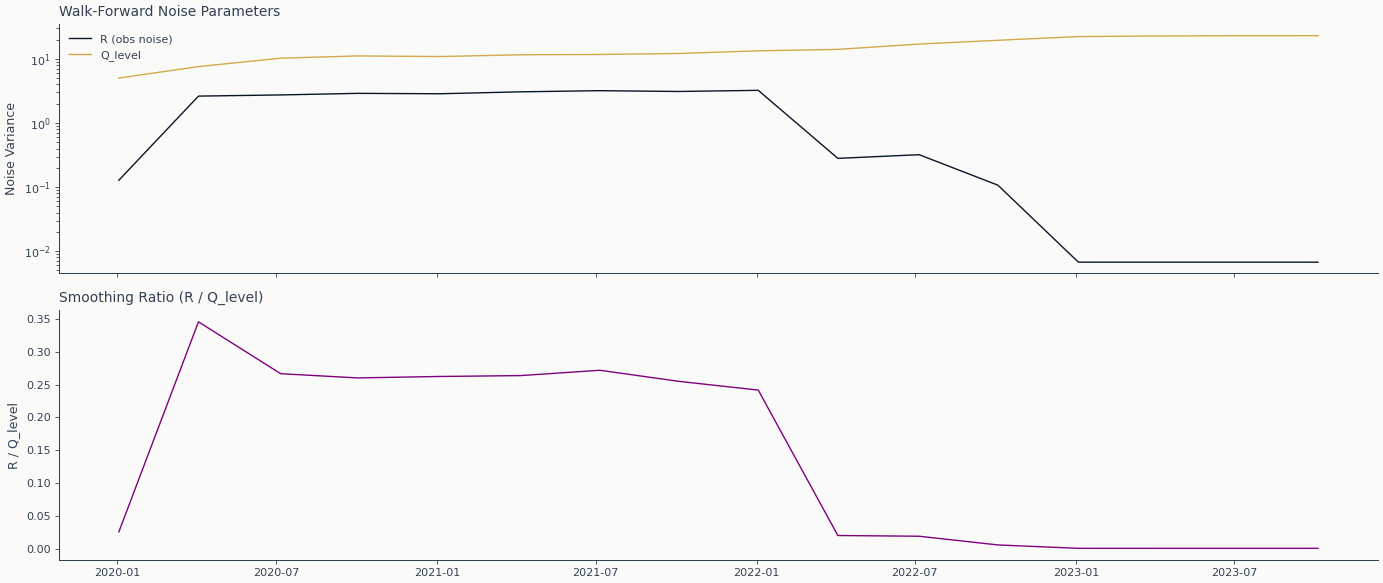

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

refit_pd = refit_df.to_pandas().set_index("timestamp")

ax = axes[0]
ax.plot(refit_pd.index, refit_pd["obs_noise"], label="R (obs noise)", linewidth=1)
ax.plot(refit_pd.index, refit_pd["level_noise"], label="Q_level", linewidth=1)
ax.set_title("Walk-Forward Noise Parameters")
ax.set_ylabel("Noise Variance")
ax.legend()
ax.set_yscale("log")

ax = axes[1]
ax.plot(refit_pd.index, refit_pd["smoothing_ratio"], linewidth=1, color="purple")
ax.set_title("Smoothing Ratio (R / Q_level)")
ax.set_ylabel("R / Q_level")

plt.tight_layout()
plt.show()

**Finding**: The smoothing ratio $R / Q_\text{level}$ varies substantially across
windows. When $R / Q_\text{level}$ is high, the filter smooths more aggressively
(trusting the state model over observations); when low, it tracks prices closely.
Walk-forward refitting captures these regime-dependent dynamics that fixed
parameters would miss.

## Feature Catalog: Kalman Filter

| Feature | Description | Use Case |
|---------|-------------|----------|
| `kalman_level` | Smoothed price estimate | Price trend |
| `kalman_trend` | Slope (trend direction) | Momentum signal |
| `kalman_innovation` | Prediction surprise | Mean reversion |
| `kalman_uncertainty` | State variance | Position sizing |
| `hedge_ratio` | Time-varying β | Pairs trading |

## Key Takeaways

1. **Four production features**: level, slope, innovation, uncertainty —
   all causal and suitable for live trading
2. **MLE estimation** of noise parameters avoids manual tuning and
   adapts to the signal-to-noise ratio
3. **Kalman slope vs rolling OLS**: Kalman adapts faster to regime changes
   because it doesn't use a fixed window
4. **Dynamic hedge ratios** capture time-varying relationships that static
   OLS misses — essential for pairs trading
5. **Walk-forward refitting** adapts noise parameters to changing market
   conditions (quarterly is a reasonable cadence)

**Next**: See `05_spectral_features` for FFT and wavelet-based features,
and `06_path_signatures` for sequence-level features.